In [ ]:
# =========================================================
# BLOCK 0 — Setup and Imports
# =========================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import matplotlib.pyplot as plt
import sklearn

# Load processed data from previous step
train = pd.read_csv("train_processed.csv")

# Separate target
y = train["RESALE_PRICE"]
X = train.drop(columns=["RESALE_PRICE"])


In [4]:
# =========================================================
# BLOCK 1 — Train a Random Forest Regressor (Baseline Numerical Only)
# =========================================================
# Select only core numeric features (no categorical)
num_features = [
    "FLOOR_AREA_SQM", "FLOOR_MIN", "FLOOR_MAX", "FLOOR_MEDIAN",
    "SALE_YEAR", "SALE_MONTH", "MONTH_IDX",
    "FLAT_AGE", "REMAINING_LEASE",
    "ROOMS", "IS_EXECUTIVE", "AREA_PER_ROOM",
    "BLOCK_NUM", "BLOCK_HAS_SUFFIX", "STREET_COUNT", "BLOCK_COUNT"
]
X_num = X[num_features].select_dtypes(include=[np.number])

X_train, X_val, y_train, y_val = train_test_split(X_num, y, test_size=0.2, random_state=42)

rf_baseline = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_baseline.fit(X_train, y_train)
preds = rf_baseline.predict(X_val)

mse = mean_squared_error(y_val, preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val, preds)
r2 = r2_score(y_val, preds)

print("=== Baseline Random Forest (Numerical Features Only) ===")
print(f"RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.4f}")


=== Baseline Random Forest (Numerical Features Only) ===
RMSE: 40080.45, MAE: 26115.85, R²: 0.9518


In [5]:
# =========================================================
# BLOCK 2 — Reduced Feature Subset (Add Categoricals Step-by-Step)
# =========================================================
# Step 1: basic numeric only (already done)
# Step 2: add categorical encodings gradually

cat_features = ["TOWN", "FLAT_TYPE", "FLAT_MODEL"]

# One-hot encode categorical columns
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_cat = encoder.fit_transform(X[cat_features])

cat_cols = encoder.get_feature_names_out(cat_features)
X_all = pd.concat(
    [X_num.reset_index(drop=True), pd.DataFrame(X_cat, columns=cat_cols)],
    axis=1
)

X_train, X_val, y_train, y_val = train_test_split(X_all, y, test_size=0.2, random_state=42)

rf_extended = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf_extended.fit(X_train, y_train)
preds = rf_extended.predict(X_val)

mse = mean_squared_error(y_val, preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val, preds)
r2 = r2_score(y_val, preds)

print("=== Random Forest with Numerical + Encoded Categorical Features ===")
print(f"RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.4f}")


=== Random Forest with Numerical + Encoded Categorical Features ===
RMSE: 32374.20, MAE: 21880.57, R²: 0.9686


In [6]:
# =========================================================
# BLOCK 3 — Encoding Check
# =========================================================
# Verify no unseen categories in test data
test = pd.read_csv("test_processed.csv")

for col in cat_features:
    unseen = set(test[col].unique()) - set(X[col].unique())
    if unseen:
        print(f"Unseen categories in {col}: {unseen}")
    else:
        print(f"No unseen categories in {col}")

# Safe one-hot transform
test_cat = encoder.transform(test[cat_features])
test_encoded = pd.concat(
    [test[num_features].reset_index(drop=True),
     pd.DataFrame(test_cat, columns=cat_cols)],
    axis=1
)
print("Encoding check complete. Test features ready for inference.")


No unseen categories in TOWN
No unseen categories in FLAT_TYPE
No unseen categories in FLAT_MODEL
Encoding check complete. Test features ready for inference.


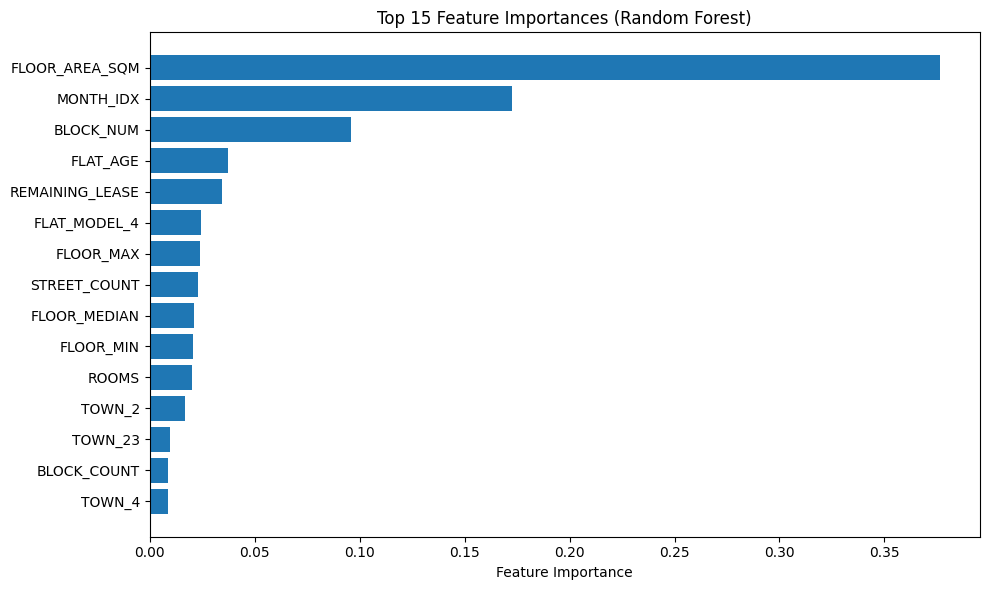

            Feature  Importance
0    FLOOR_AREA_SQM    0.376668
1         MONTH_IDX    0.172601
2         BLOCK_NUM    0.096101
3          FLAT_AGE    0.037536
4   REMAINING_LEASE    0.034591
5      FLAT_MODEL_4    0.024536
6         FLOOR_MAX    0.024068
7      STREET_COUNT    0.023010
8      FLOOR_MEDIAN    0.020932
9         FLOOR_MIN    0.020717
10            ROOMS    0.019967
11           TOWN_2    0.016790
12          TOWN_23    0.009727
13      BLOCK_COUNT    0.008934
14           TOWN_4    0.008608


In [7]:
# =========================================================
# BLOCK 4 — Feature Importance
# =========================================================
importances = rf_extended.feature_importances_
indices = np.argsort(importances)[::-1]
top_k = 15

plt.figure(figsize=(10, 6))
plt.barh(range(top_k), importances[indices[:top_k]][::-1])
plt.yticks(range(top_k), np.array(X_all.columns)[indices[:top_k]][::-1])
plt.xlabel("Feature Importance")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

# Print ranked list
ranked = pd.DataFrame({
    "Feature": np.array(X_all.columns)[indices],
    "Importance": importances[indices]
})
print(ranked.head(15))


In [8]:
# =========================================================
# BLOCK 5 — Hyperparameter Sensitivity (Small Grid Search)
# =========================================================
param_grid = {
    "n_estimators": [100, 200, 400],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=1
)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best RMSE:", -grid.best_score_)


Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 400}
Best RMSE: 34608.627317530874
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 400}
Best RMSE: 34608.627317530874


Permutation Importance (Top 10):
            Feature  Permutation Importance
0    FLOOR_AREA_SQM                0.793676
6         MONTH_IDX                0.362326
12        BLOCK_NUM                0.226784
7          FLAT_AGE                0.087329
8   REMAINING_LEASE                0.081253
14     STREET_COUNT                0.045659
18           TOWN_2                0.029542
39          TOWN_23                0.026760
20           TOWN_4                0.025693
25           TOWN_9                0.025660


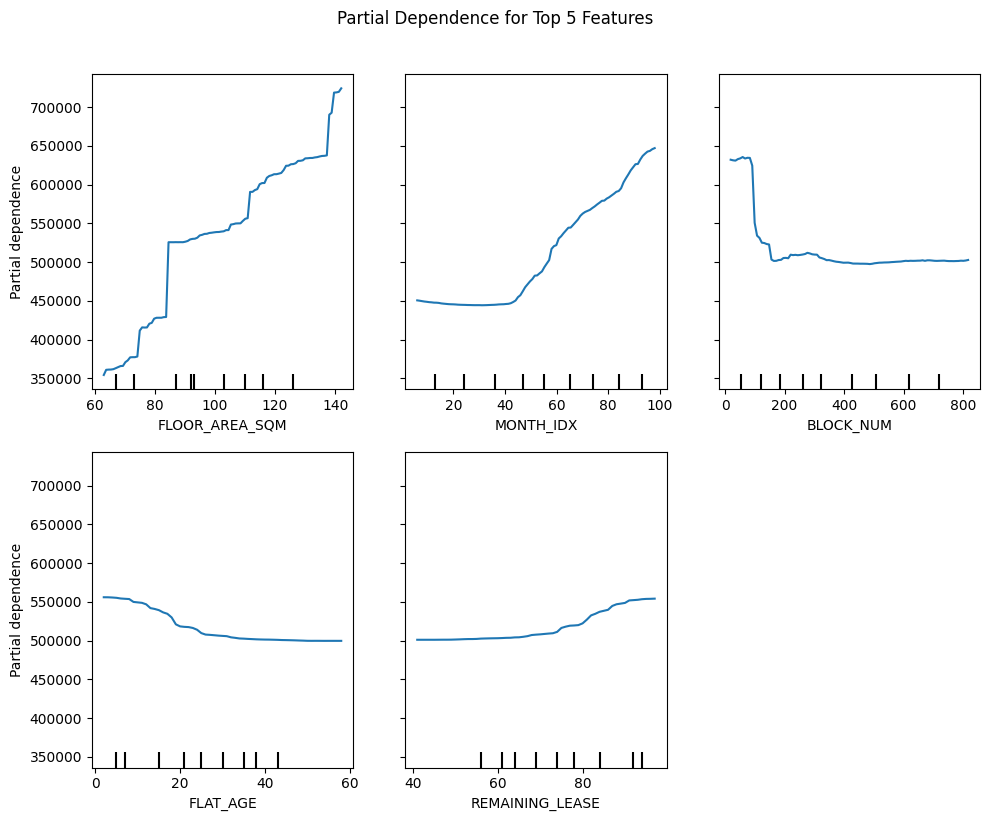

In [9]:
# =========================================================
# BLOCK 6 — Interpretability (Partial Dependence + Permutation)
# =========================================================
# Select top 5 features for interpretation
top_features = ranked["Feature"].iloc[:5].tolist()

# Permutation importance
perm_result = permutation_importance(rf_extended, X_val, y_val, n_repeats=5, random_state=42, n_jobs=-1)
perm_importance = pd.DataFrame({
    "Feature": X_all.columns,
    "Permutation Importance": perm_result.importances_mean
}).sort_values("Permutation Importance", ascending=False)
print("Permutation Importance (Top 10):")
print(perm_importance.head(10))

# Partial Dependence Plots
fig, ax = plt.subplots(figsize=(10, 8))
PartialDependenceDisplay.from_estimator(
    rf_extended,
    X_val,
    features=top_features,
    ax=ax
)
plt.suptitle("Partial Dependence for Top 5 Features", y=1.02)
plt.tight_layout()
plt.show()
